Epoch [1/10], Loss: 1.1232
Epoch [2/10], Loss: 1.0896
Epoch [3/10], Loss: 0.9169
Epoch [4/10], Loss: 1.0907
Epoch [5/10], Loss: 0.7397
Epoch [6/10], Loss: 0.8255
Epoch [7/10], Loss: 0.8496
Epoch [8/10], Loss: 0.8434
Epoch [9/10], Loss: 0.8401
Epoch [10/10], Loss: 0.8442
Model saved as 'unet_satellite.pth'


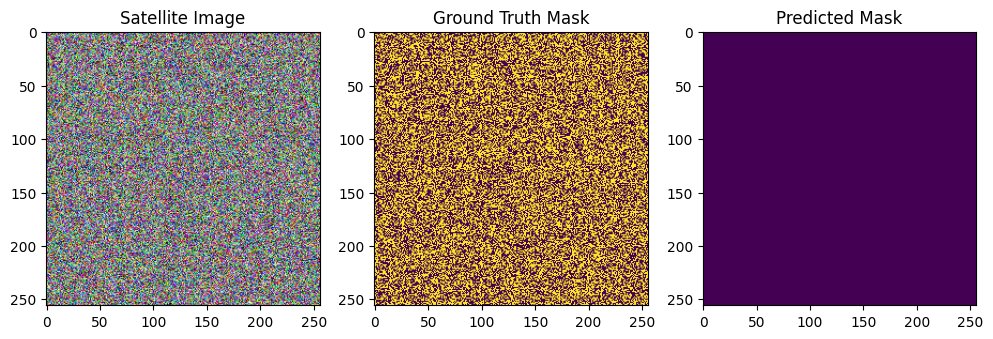

Predicted masks saved in 'predicted_masks'


In [ ]:
#

import os

import torch

import torch.nn as nn

import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from PIL import Image

import numpy as np

import matplotlib.pyplot as plt

#Dataset Class

#

class SatelliteDataset (Dataset):

    def __init__(self, image_dir, mask_dir, transform=None):

        self.image_dir = image_dir

        self.mask_dir = mask_dir

        self.transform = transform

        self.images = os.listdir(image_dir)

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        img_path= os.path.join(self.image_dir, self.images[idx])

        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = np.array(Image.open(img_path).convert("RGB"))

        mask = np.array(Image.open(mask_path).convert("L"))

        if self.transform:

            augmented = self.transform(image=image, mask=mask)

            image = augmented['image']

            mask = augmented['mask']

        image = transforms.ToTensor() (image)

        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask
#UNet Model

class DoubleConv(nn.Module):

    def __init__(self, in_ch, out_ch):

        super (DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_ch, out_ch, 3, padding=1),

            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),

            nn.ReLU(inplace=True)
        )
    def forward(self, x):

        return self.conv(x)

class UNet(nn.Module):

    def __init__(self, n_classes):

        super(UNet, self).__init__()

        self.dconv_down1 = DoubleConv(3, 64)

        self.dconv_down2 = DoubleConv(64, 128)

        self.dconv_down3 = DoubleConv(128, 256)

        self.maxpool = nn.MaxPool2d(2)

        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.dconv_up2 = DoubleConv(256+128, 128)
        self.dconv_up1 = DoubleConv (128+64, 64)

        self.conv_last = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):

        # Encoder

        conv1= self.dconv_down1(x)

        x= self.maxpool (conv1)

        conv2= self.dconv_down2(x)

        x= self.maxpool (conv2)

        x= self.dconv_down3(x)

        # Decoder

        # This part needs to be reviewed as the code is incomplete/malformed
        # It seems like there's a missing assignment or a variable name for the upsampled output
        # and then the torch.cat is also standalone without assignment.
        # Assuming the intent was something like:


        x = self.upsample(x) # Fixed assignment
        x = torch.cat([x, conv2], dim=1) # Fixed assignment

        x= self.dconv_up2(x)

        x= self.upsample(x)

        x = torch.cat([x, conv1], dim=1)

        x= self.dconv_up1(x)

        x = self.conv_last(x)

        return x

# Hyperparameters
batch_size=4

lr = 1e-3 # Corrected typo from '1r 1e-3'

num_epochs = 10

n_classes = 3

#Load Dataset

#Create dummy directories for images and masks to prevent FileNotFoundError

#In a real scenario, you would upload your dataset to these paths or mount Google Drive.

os.makedirs("images/train", exist_ok=True)

os.makedirs("masks/train", exist_ok=True)

#Create dummy image and mask files to avoid empty dataset error

dummy_image = Image.fromarray(np.random.randint(0, 255, (256, 256, 3), dtype=np.uint8))
dummy_mask = Image.fromarray(np.random.randint(0, n_classes - 1, (256, 256), dtype=np.uint8))

dummy_image.save("images/train/dummy_image.png")
dummy_mask.save("masks/train/dummy_image.png")

train_dataset = SatelliteDataset("images/train", "masks/train")

train_loader = DataLoader (train_dataset, batch_size=batch_size, shuffle=True)
#Device, Model, Loss, Optimizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Corrected 'cри'

model = UNet(n_classes=n_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=lr) # Corrected assignment

#Training Loop

#

for epoch in range(num_epochs):

    model.train()

    epoch_loss = 0.0 # Initialized epoch_loss

    for imgs, masks in train_loader:

        imgs = imgs.to(device) # Corrected assignment
        masks = masks.to(device) # Corrected assignment

        outputs = model(imgs)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(train_loader):.4f}") # Fixed f-string

#

#Save Model
torch.save(model.state_dict(), "unet_satellite.pth")

print("Model saved as 'unet_satellite.pth'") # Fixed quotes


#Visualize Predictions

# Removed 'ge.png' as it's not a valid Python statement

model.eval()

sample_img, sample_mask = train_dataset[0] # Corrected assignment

with torch.no_grad():

    pred = model(sample_img.unsqueeze(0).to(device))

    pred_mask = torch.argmax(pred.squeeze(), dim=0).cpu().numpy() # Corrected 'dim-0'

# Removed 'ge.png' as it's not a valid Python statement

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)

plt.imshow(sample_img.permute(1,2,0))

plt.title("Satellite Image")

plt.subplot(1,3,2)

plt.imshow(sample_mask)

plt.title("Ground Truth Mask")

plt.subplot(1,3,3)

plt.imshow(pred_mask)

plt.title("Predicted Mask")

plt.show()

#Save Predicted Masks
os.makedirs("predicted_masks", exist_ok=True)

for i in range(len(train_dataset)):

    img, _ = train_dataset[i] # Corrected assignment and ignored mask since not used

    with torch.no_grad():

        pred = model(img.unsqueeze(0).to(device)) # Corrected 'unsqueeze(8)' to 'unsqueeze(0)'

        pred_mask = torch.argmax(pred.squeeze(), dim=0).cpu().numpy() # Corrected 'dim=8' to 'dim=0'

    mask_img = Image.fromarray(pred_mask.astype(np.uint8)) # Corrected 'np.uints' to 'np.uint8'

    mask_img.save(f"predicted_masks/mask_{i}.png")

print("Predicted masks saved in 'predicted_masks'")

In [7]:
import streamlit as st
import time
from datetime import datetime
import json
import random

# Page config
st.set_page_config(
    page_title="Live Meeting Summarizer",
    page_icon="🎙",
    layout="wide"
)

# --- Initialize session state ---
if 'is_recording' not in st.session_state:
    st.session_state.is_recording = False
if 'transcript' not in st.session_state:
    st.session_state.transcript = []
if 'summary' not in st.session_state:
    st.session_state.summary = ""
if 'key_points' not in st.session_state:
    st.session_state.key_points = []
if 'action_items' not in st.session_state:
    st.session_state.action_items = []

# --- Title and header ---
st.title("🎙 Live Meeting Summarizer")
st.markdown("Real-time transcription and intelligent meeting summarization")

# --- Sidebar for controls ---
with st.sidebar:
    st.header("Meeting Controls")

    # Recording controls
    col1, col2 = st.columns(2)
    with col1:
        if st.button("► Start", disabled=st.session_state.is_recording, use_container_width=True):
            st.session_state.is_recording = True
            st.rerun()
    with col2:
        if st.button("■ Stop", disabled=not st.session_state.is_recording, use_container_width=True):
            st.session_state.is_recording = False
            st.rerun()

    if st.button("🗑 Clear All Data", use_container_width=True):
        st.session_state.transcript = []
        st.session_state.summary = ""
        st.session_state.key_points = []
        st.session_state.action_items = []
        st.rerun()
    st.divider()

    # Meeting info
    st.subheader("Meeting Info")
    meeting_title = st.text_input("Meeting Title", "Team Standup")
    participants = st.text_area("Participants", "John, Sarah, Mike")

    st.divider()
    # Settings
    st.subheader("Settings")
    # Using a local variable for interval as actual auto-summarization logic isn't implemented in this simulated code
    summarize_interval = st.slider("Auto-summarize every (seconds)", 30, 300, 60)
    language = st.selectbox("Language", ["English", "Spanish", "French", "German", "Chinese"])

    # Status indicator
    st.divider()
    if st.session_state.is_recording:
        st.success("🎙 Recording in progress...")
    else:
        st.info("🛑 Not recording")

# --- Main content area with tabs ---
tab1, tab2, tab3, tab4 = st.tabs((" Live Transcript", "Summary", "Action Items", "Export"))

with tab1:
    st.subheader("Live Transcription")

    # Transcript display area
    # Use a fixed height container for consistent scrolling
    transcript_container = st.container(height=500)

    with transcript_container:
        if st.session_state.transcript:
            # Display entries in reverse order so the newest are at the top (simulating a live feed)
            for entry in reversed(st.session_state.transcript):
                timestamp = entry.get('timestamp', '')
                speaker = entry.get('speaker', 'Unknown')
                text = entry.get('text', '')
                col1, col2 = st.columns([1, 5])
                with col1:
                    st.caption(f"{speaker}")
                    st.caption(timestamp)
                with col2:
                    st.write(text)
                st.divider()
        else:
            st.info("No transcript available. Start recording to begin transcription.")

    # Simulate live transcription (replace with actual transcription API)
    if st.session_state.is_recording:
        sample_speakers = ["Alice", "Bob", "Charlie"]
        sample_texts = [
            "Let's discuss the progress on the new feature.",
            "I've completed the backend implementation.",
            "The frontend integration is 80% done.",
            "We need to address the performance issues.",
            "I'll work on the documentation this week.",
            "Can we schedule a code review for tomorrow?"
        ]

        # Add new transcript entry (simulated) every 0.5 seconds
        import random
        new_entry = {
            'timestamp': datetime.now().strftime("%H:%M:%S"),
            'speaker': random.choice(sample_speakers),
            'text': random.choice(sample_texts)
        }
        st.session_state.transcript.append(new_entry)
        time.sleep(0.5)
        # Rerun the script to update the UI and continue the simulation loop
        st.rerun()

with tab2:
    st.subheader("Meeting Summary & Key Points")

    col1, col2 = st.columns([3, 1])
    with col2:
        if st.button("✨ Generate Summary", use_container_width=True):
            # Simulate summary generation (replace with actual AI summarization)
            if st.session_state.transcript:
                with st.spinner("Generating summary..."):
                    time.sleep(2)
                    st.session_state.summary = f"""
*Meeting:* {meeting_title}

Main Topics Discussed:
*   Backend implementation status
*   Frontend integration progress (80% complete)
*   Performance optimization needs
*   Documentation requirements
*   Code review scheduling

*Decisions Made:*
*   Schedule code review for tomorrow
*   Prioritize performance issue resolution
*   Assign documentation tasks for this week
"""
                    st.session_state.key_points = [
                        "Backend implementation completed",
                        "Frontend integration 80% done",
                        "Performance issues identified",
                        "Code review scheduled for tomorrow",
                        "Documentation work assigned"
                    ]
                    st.success("Summary generated successfully!")
                    st.rerun() # Rerun to update the display immediately
            else:
                st.warning("Please record some transcript first to generate a summary.")

    if st.session_state.summary:
        st.markdown(st.session_state.summary)
        st.subheader("Key Points")
        for i, point in enumerate(st.session_state.key_points, 1):
            st.markdown(f"- {point}")
    else:
        st.info("Generate a summary to see the meeting overview and key points.")

with tab3:
    st.subheader("Action Items")

    if st.button("📋 Extract Action Items", use_container_width=False):
        # Simulate action item extraction (replace with actual AI extraction)
        if st.session_state.transcript:
            with st.spinner("Extracting action items..."):
                time.sleep(1.5)
                # Fixed syntax errors in data structure and added missing deadlines
                st.session_state.action_items = [
                    {"task": "Complete frontend integration", "assignee": "Bob", "deadline": "EOD Friday"},
                    {"task": "Address performance issues", "assignee": "Charlie", "deadline": "Next Week"},
                    {"task": "Write documentation", "assignee": "Alice", "deadline": "EOD Wednesday"},
                    {"task": "Conduct code review", "assignee": "Team", "deadline": "Tomorrow"}
                ]
                st.success("Action items extracted!")
                st.rerun()
        else:
             st.warning("Please record some transcript first to extract action items.")

    if st.session_state.action_items:
        for i, item in enumerate(st.session_state.action_items, 1):
            # Fixed key variable for the checkbox
            with st.expander(f"Action Item {i}: {item['task']}", expanded=True):
                col1, col2, col3 = st.columns(3)
                with col1:
                    st.write(f"Assignee: {item['assignee']}")
                with col2:
                    st.write(f"Deadline: {item['deadline']}")
                with col3:
                    # Unique key required for every element
                    st.checkbox("Completed", key=f"action_{i}")
    else:
        st.info("Extract action items to see tasks and assignments from the meeting.")

with tab4:
    st.subheader("Export Meeting Data")

    col1, col2, col3 = st.columns(3)

    with col1:
        # Generate export text content
        export_text = f"Meeting: {meeting_title}\n"
        export_text += f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n"
        export_text += f"Participants: {participants}\n\n"
        export_text += "=== TRANSCRIPT ===\n"

        for entry in st.session_state.transcript:
            # Fixed typo in key access for 'timestamp' and 'speaker'
            export_text += f"[{entry['timestamp']}] {entry['speaker']}: {entry['text']}\n"

        export_text += f"\n=== SUMMARY ===\n{st.session_state.summary}\n"

        st.download_button(
            label="⬇ Download Text File",
            data=export_text,
            file_name=f"meeting_{datetime.now().strftime('%Y%m%d_%H%M')}.txt",
            mime="text/plain",
            use_container_width=True
        )

    with col2:
        # Generate export JSON content
        export_data = {
            "meeting_title": meeting_title,
            "date": datetime.now().strftime('%Y-%m-%d %H:%M'),
            "participants": participants,
            "transcript": st.session_state.transcript,
            "summary": st.session_state.summary,
            "key_points": st.session_state.key_points,
            "action_items": st.session_state.action_items
        }

        st.download_button(
            label="⬇ Download JSON File",
            data=json.dumps(export_data, indent=2),
            file_name=f"meeting_{datetime.now().strftime('%Y%m%d_%H%M')}.json",
            mime="application/json",
            use_container_width=True
        )

    with col3:
        if st.button("📧 Email Summary", use_container_width=True):
            st.info("Email functionality would be implemented here with SMTP or an email service API.")

# --- Footer ---
st.divider()
st.caption("Live Meeting Summarizer v1.0 | Powered by Streamlit")

2025-12-16 15:57:21.304 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 15:57:21.304 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 15:57:21.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 15:57:21.309 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 15:57:21.311 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 15:57:21.312 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 15:57:21.314 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 15:57:21.316 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [6]:
!pip install streamlit
import streamlit as st
import time
from datetime import datetime

import json

# Page config
st.set_page_config(
    page_title="Live Meeting Summarizer",
    page_icon="",
    layout="wide"
)

# Initialize session state
if 'is_recording' not in st.session_state:
    st.session_state.is_recording = False
if 'transcript' not in st.session_state:
    st.session_state.transcript = []
if 'summary' not in st.session_state:
    st.session_state.summary = ""
if 'key_points' not in st.session_state:
    st.session_state.key_points = []
if 'action_items' not in st.session_state:
    st.session_state.action_items = []

# Title and header
st.title(" Live Meeting Summarizer")
st.markdown("Real-time transcription and intelligent meeting summarization")

# Sidebar for controls
with st.sidebar:
    st.header("Meeting Controls")

    #Recording controls
    col1, col2 = st.columns(2)
    with col1:
        if st.button("► Start", disabled=st.session_state.is_recording, use_container_width=True):
            st.session_state.is_recording = True
            st.rerun()
    with col2:
        if st.button("■ Stop", disabled=not st.session_state.is_recording, use_container_width=True):
            st.session_state.is_recording = False
            st.rerun()

    if st.button("🗑️ Clear All", use_container_width=True):
        st.session_state.transcript = []
        st.session_state.summary = ""
        st.session_state.key_points = []
        st.session_state.action_items = []
        st.rerun()
    st.divider()

    # Meeting info
    st.subheader("Meeting Info")
    meeting_title = st.text_input("Meeting Title", "Team Standup")
    participants = st.text_area ("Participants", "John, Sarah, Mike")

    st.divider()
    # Settings
    st.subheader("Settings")
    summarize_interval = st.slider("Auto-summarize every (seconds)", 30, 300, 60)
    language = st.selectbox("Language", ["English", "Spanish", "French", "German", "Chinese"])

    #Status indicator
    st.divider()
    if st.session_state.is_recording:
        st.success("🎙️ Recording in progress...")
    else:
        st.info("🛑 Not recording")

# Main content area with tabs
tab1, tab2, tab3, tab4 = st.tabs((" Live Transcript", "Summary", "Action Items", "Key Points"))

with tab1:
    st.subheader("Live Transcription")

    # Transcript display area
    transcript_container = st.container(height=500)

    with transcript_container:
        if st.session_state.transcript:
            for entry in st.session_state.transcript:
                timestamp = entry.get('timestamp', '')
                speaker = entry.get('speaker', 'Unknown')
                text = entry.get('text', '')
                col1, col2 = st.columns([1, 5])
                with col1:
                    st.caption(f"{speaker}")
                    st.caption(timestamp)
                with col2:
                    st.write(text)
                st.divider()
        else:
            st.info("No transcript available. Start recording to begin transcription.")

    # Simulate live transcription (replace with actual transcription API)
    if st.session_state.is_recording:
        sample_speakers = ["Alice", "Bob", "Charlie"]
        sample_texts = [
            "Let's discuss the progress on the new feature.",
            "I've completed the backend implementation.",
            "The frontend integration is 80% done.",
            "We need to address the performance issues.",
            "I'll work on the documentation this week.",
            "Can we schedule a code review for tomorrow?"
        ]

        #Add new transcript entry (simulated)
        if len(st.session_state.transcript) < 10:
            import random
            new_entry = {
                'timestamp': datetime.now().strftime("%H:%M:%S"),
                'speaker': random.choice(sample_speakers),
                'text': random.choice(sample_texts)
            }
            st.session_state.transcript.append(new_entry)
            time.sleep(0.1)
            st.rerun()

with tab2:
    st.subheader("Meeting Summary")

    col1, col2 = st.columns([3, 1])
    with col2:
        if st.button("✨ Generate Summary", use_container_width=True):
            # Simulate summary generation (replace with actual AI summarization)
            if st.session_state.transcript:
                with st.spinner("Generating summary..."):
                    time.sleep(2)
                    st.session_state.summary = """
The team discussed progress on the new feature development. Key accomplishments:

*Main Topics:*
Backend implementation status
Frontend integration progress (80% complete)
Performance optimization needs
Documentation requirements
Code review scheduling

**Decisions Made:**
Schedule code review for tomorrow
Prioritize perform
Assign documentation tasks for this week###

]

147

148

st.session_state.key_points = [

149

"Backend implementation completed",

150

"Frontend integration 80% done",

151

"Performance issues identified",

152

"Code review scheduled for tomorrow",

153

"Documentation work assigned"

154

155

st.success("Summary generated successfully!")

156

st.rerun()

158

if st.session_state.summary:

159

st.markdown(st.session_state.summary)

160

161

st.subheader("Key Points")ance issue resolution
for i, point in enumerate (st.session_state.key_points, 1):

163

st.markdown(f"{i}. {point}")

164

else:

165

166

st.info("Generate a summary to see the meeting overview and key points.

167 with tab3:

168

st.subheader("Action Items")

169

170

if st.button(" Extract Action Items", use_container_width=False):

171

172

# Simulate action item extraction (replace with actol AI extraction)

173

if st.session_state.transcript:

with st.spinner ("Extracting action items..."):


  time.sleep(1.5)

st.session_state.action_items = [

176

{"task": "Complete frontend integration", "assignee": "Bob",

177

{"task": "Address performance issues", "assignee": "Charlie"

178

"task": "Write documentation", "assignee": "Alice", "deadli

X

179

{ {"task": "Conduct code review", "assignee": "Team", "deadlin

st.success("Action items extracted!")

181

st.rerun()

182

183

if st.session_state.action_items:

184

for i, item in enumerate (st.session_state.action_items, 1):

185

with st.expander (f"Action Item {i}: {item['task']}", expanded=True):

186

col1, col2, col3 = st.columns(3)

187

with col1:

188

st.write(f"*Assignee:* {item['assignee']}")

189

with col2:

190

st.write(f"*Deadline:* {item['deadline']}")

191

with col3:

192

st.checkbox("Completed", key=f"action_{}")

193

else:

194

]
else:

194

195

st.info("Extract action items to see tasks and assignments from the meet

196

197

with tab4:

198

st.subheader("Export Meeting Data")

199

200

col1, col2, col3 = st.columns(3)

201

202

with col1:

203

if st.button(" Export as Text", use_container_width=True):

204

export_text = f"Meeting: {meeting_title}\n"

205

export_text += f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n

206

export_text += f"Participants: {participants}\n\n"

207

export_text += "=== TRANSCRIPT ===\n"

208

209

for entry in st.session_state.transcript:

210

export_text += f"[{entry['timestamp')}) {enary['speaker']}: {ent

211

export_text += f"\n=== SUMMARY ===\n{st.session_state.summary}\n"

st.download_button(

213

label="Download Text File",

214

data=export_text,

file_name=f"meeting_{datetime.now().strftime('%Y%m%d_

216

mime="text/plain"

217

(

218

with col2:

220

if st.button(" Export as JSON", use_container_width=True):

221

export_data = {

222

"meeting_title": meeting_title,

223

"date": datetime.now().strftime('%Y-%m-%d %H:%M'),
"participants": participants,

225

"transcript": st.session_state.transcript,

226

"summary": st.session_state.summary,

227

"key_points": st.session_state.key_points,

228

"action_items": st.session_state.action_items

229

}

230

st.download_button(

231

232

label="Download JSON File",

233

data=json.dumps(export_data, indent=2),

234

235

file_name=f"meeting_{datetime.now().strftime('%Y%m%d_%H%M')}.jso

mime="application/json"

236

)

237

238

with col3:
  if st.button(" Email Summary", use_container_width=True):

240

st.info("Email functionality would be implemented here with SMTP

241

242 # Footer

243

st.divider()

244 st.caption("Live Meeting Summarizer v1.0 | Powered")
"""

2025-12-16 15:54:05.114 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 15:54:05.115 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 15:54:05.117 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 15:54:05.119 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 15:54:05.122 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 15:54:05.123 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 15:54:05.125 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-16 15:54:05.125 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar